In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_curve, auc, RocCurveDisplay,confusion_matrix, classification_report,ConfusionMatrixDisplay)

c:\Users\LENOVO\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('../data/nvda_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])

for i in range(1, 6):
    df[f'lag{i}'] = df['Returns'].shift(i)

df['direction'] = (df['Returns'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'Rolling Std']
X = df[features]
y = df['direction']

print(f"Class balance — Up: {y.mean():.2%}, Down: {1-y.mean():.2%}")

Class balance — Up: 53.88%, Down: 46.12%


In [3]:
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 1587 | Test: 397


In [6]:
lr = LogisticRegression(class_weight='balanced', random_state=42)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Models trained successfully")

Models trained successfully


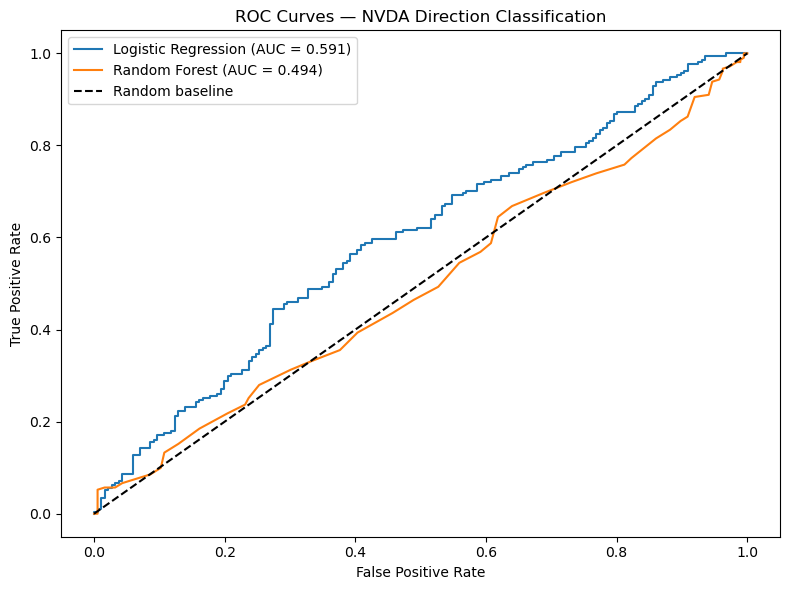

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, name in [(lr, 'Logistic Regression'), (rf, 'Random Forest')]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — NVDA Direction Classification')
ax.legend()
plt.tight_layout()
plt.show()

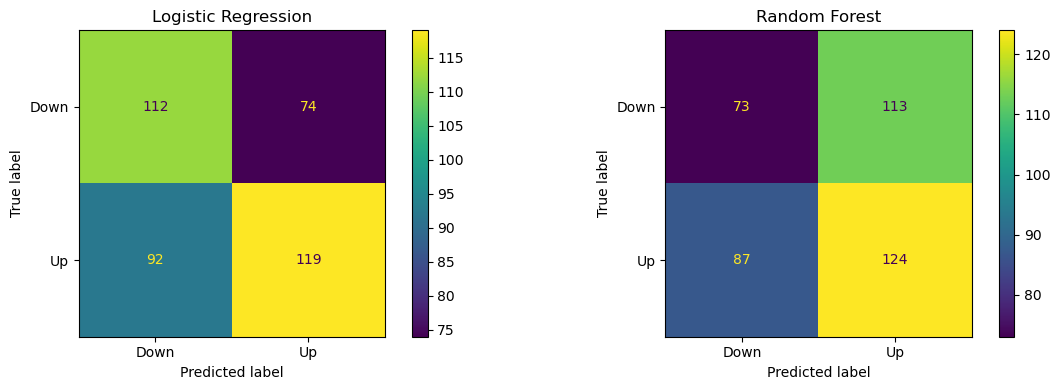

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name in zip(axes, [lr, rf], ['Logistic Regression', 'Random Forest']):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=ax)
    ax.set_title(f'{name}')

plt.tight_layout()
plt.show()

In [9]:
for model, name in [(lr, 'Logistic Regression'), (rf, 'Random Forest')]:
    print(f"\n{name}")
    print(classification_report(y_test, model.predict(X_test), target_names=['Down', 'Up']))


Logistic Regression
              precision    recall  f1-score   support

        Down       0.55      0.60      0.57       186
          Up       0.62      0.56      0.59       211

    accuracy                           0.58       397
   macro avg       0.58      0.58      0.58       397
weighted avg       0.58      0.58      0.58       397


Random Forest
              precision    recall  f1-score   support

        Down       0.46      0.39      0.42       186
          Up       0.52      0.59      0.55       211

    accuracy                           0.50       397
   macro avg       0.49      0.49      0.49       397
weighted avg       0.49      0.50      0.49       397

